In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import io

putanja = "data/upsell_diplomski.xlsx"

sirovo = pd.read_excel(putanja)
tekst = sirovo.columns[0] + "\n" + "\n".join(sirovo.iloc[:, 0].astype(str))
df = pd.read_csv(io.StringIO(tekst))

print("Dimenzije baze:", df.shape)

Dimenzije baze: (592839, 50)


In [3]:

user_ids = df['user_id']          # sacuvaj identifikatore pre izbacivanja

df.drop(columns=['user_id', 'tariff_number_after_renewal', 'Steel_phone'], inplace=True, errors='ignore')

df = df.dropna()

print("Novi oblik tabele:", df.shape)
df.info()

<class 'pandas.DataFrame'>
Index: 590759 entries, 0 to 592838
Data columns (total 47 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   upsell                               590759 non-null  int64  
 1   tariff_number_before_renewal         590759 non-null  str    
 2   Adequate_Tariff_Flag                 590759 non-null  int64  
 3   Moj_A1_purchase_trend                590759 non-null  int64  
 4   Elderly_Age_segment                  590759 non-null  int64  
 5   Regular_Traveler_Flag                590759 non-null  int64  
 6   Last_Payment_Channel_BankPayments    590759 non-null  int64  
 7   Moderate_MOU_Flag                    590759 non-null  int64  
 8   No_phone                             590759 non-null  int64  
 9   Very_Heavy_SMS_Flag                  590759 non-null  int64  
 10  Heavy_MOU_Flag                       590759 non-null  int64  
 11  Weekend_Traveler_Flag        

In [4]:


df['tariff_number_before_renewal'] = df['tariff_number_before_renewal'].str.strip('" ')

vazne_tarife = ['Tariff 1', 'Tariff 2', 'Tariff 3', 'Tariff 3a', 'Tariff 3b', 'Tariff 4', 'Tariff 5', 'Tariff 6']
df = df[df['tariff_number_before_renewal'].isin(vazne_tarife)]


df_final = pd.get_dummies(df, columns=['tariff_number_before_renewal'], prefix='T', drop_first=False, dtype=int)

print(df_final.filter(like='T_Tariff').columns.tolist())

display(df_final.head())
print(df_final.columns.tolist())

print("Info o kolonama:")
df_final.info()

print("Statistika:")
display(df_final.describe())

,upsell,Adequate_Tariff_Flag,Moj_A1_purchase_trend,Elderly_Age_segment,Regular_Traveler_Flag,Last_Payment_Channel_BankPayments,Moderate_MOU_Flag,No_phone,Very_Heavy_SMS_Flag,Heavy_MOU_Flag,...,Send_Mail_6_Months,Migration_Flag,T_Tariff 1,T_Tariff 2,T_Tariff 3,T_Tariff 3a,T_Tariff 3b,T_Tariff 4,T_Tariff 5,T_Tariff 6
count,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,...,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.00000,590731.000000,590731.000000
mean,0.283034,0.413982,0.040179,0.163142,0.177296,0.337225,0.338704,0.251060,0.130471,0.284070,...,0.295471,0.130667,0.084028,0.210233,0.193059,0.008305,0.091079,0.32606,0.086706,0.000530
std,0.450473,0.492546,0.649945,0.369495,0.381919,0.472763,0.473269,0.433623,0.336821,0.450971,...,0.456255,0.337036,0.277430,0.407474,0.394699,0.090752,0.287721,0.46877,0.281404,0.023012
min,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [5]:

df_final.info()
print(df_final['upsell'].value_counts())

<class 'pandas.DataFrame'>
Index: 590731 entries, 0 to 592838
Data columns (total 54 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   upsell                               590731 non-null  int64  
 1   Adequate_Tariff_Flag                 590731 non-null  int64  
 2   Moj_A1_purchase_trend                590731 non-null  int64  
 3   Elderly_Age_segment                  590731 non-null  int64  
 4   Regular_Traveler_Flag                590731 non-null  int64  
 5   Last_Payment_Channel_BankPayments    590731 non-null  int64  
 6   Moderate_MOU_Flag                    590731 non-null  int64  
 7   No_phone                             590731 non-null  int64  
 8   Very_Heavy_SMS_Flag                  590731 non-null  int64  
 9   Heavy_MOU_Flag                       590731 non-null  int64  
 10  Weekend_Traveler_Flag                590731 non-null  int64  
 11  Headphones_Flag_Last_Contract

In [6]:
df_final.describe()

,upsell,Adequate_Tariff_Flag,Moj_A1_purchase_trend,Elderly_Age_segment,Regular_Traveler_Flag,Last_Payment_Channel_BankPayments,Moderate_MOU_Flag,No_phone,Very_Heavy_SMS_Flag,Heavy_MOU_Flag,...,Send_Mail_6_Months,Migration_Flag,T_Tariff 1,T_Tariff 2,T_Tariff 3,T_Tariff 3a,T_Tariff 3b,T_Tariff 4,T_Tariff 5,T_Tariff 6
count,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,...,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.00000,590731.000000,590731.000000
mean,0.283034,0.413982,0.040179,0.163142,0.177296,0.337225,0.338704,0.251060,0.130471,0.284070,...,0.295471,0.130667,0.084028,0.210233,0.193059,0.008305,0.091079,0.32606,0.086706,0.000530
std,0.450473,0.492546,0.649945,0.369495,0.381919,0.472763,0.473269,0.433623,0.336821,0.450971,...,0.456255,0.337036,0.277430,0.407474,0.394699,0.090752,0.287721,0.46877,0.281404,0.023012
min,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


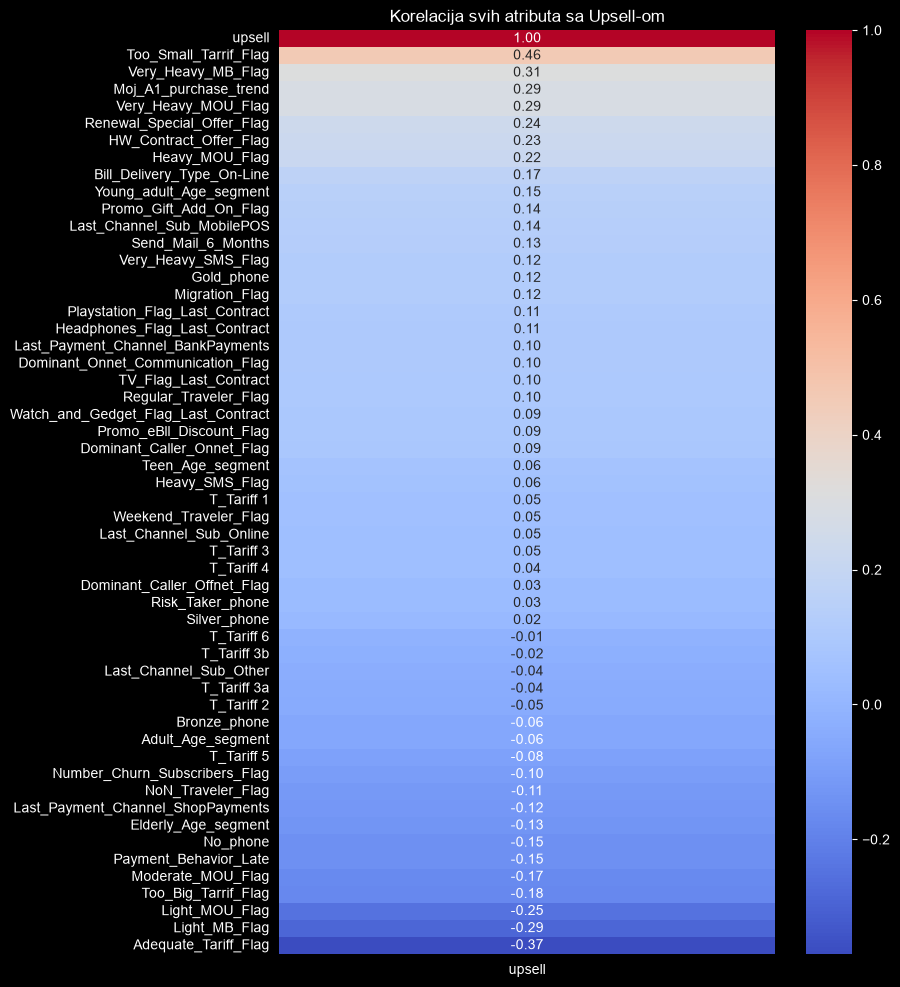

In [7]:
target_corr = df_final.corr()['upsell'].sort_values(ascending=False)

plt.figure(figsize=(8, 12))
sns.heatmap(target_corr.to_frame(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelacija svih atributa sa Upsell-om")
plt.show()